In [1]:
import pandas as pd
import numpy as np
import torch
import random
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
!pip install fairlearn
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 13.9 MB/s eta 0:00:00


In [2]:
# load dataset
df = pd.read_csv('dreaddit_train_cleaned.csv')

age_group_mapping = {
    "13-17": 0,
    "18-24": 1,
    "25-34": 2,
    "35-49": 3,
    "50+": 4,
    "unknown": -1
}
df['age_label'] = df['age_group'].map(age_group_mapping)

In [3]:
df['gender_binary'] = df['gender'].apply(lambda x: 1 if str(x).lower() in ['male', 'm'] else 0)

In [4]:
df = df.dropna(subset=['text', 'label', 'age_label'])
df = df[df['age_label'] != -1]

In [5]:
def apply_cda_structured(df, protected_attribute='age_group'):
    augmented_rows = []
    unique_values = df[protected_attribute].unique()
    unique_values = [v for v in unique_values if v != 'unknown']

    for idx, row in df.iterrows():
        current_value = row[protected_attribute]
        if current_value == 'unknown':
            continue
        new_value = random.choice([v for v in unique_values if v != current_value])
        augmented_row = row.copy()
        augmented_row[protected_attribute] = new_value
        augmented_rows.append(augmented_row)

    augmented_df = pd.DataFrame(augmented_rows)
    print(f"✅ Generated {len(augmented_df)} counterfactual samples")
    return pd.concat([df, augmented_df]).reset_index(drop=True)

augmented_df = apply_cda_structured(df)

✅ Generated 2342 counterfactual samples


In [6]:
# Split data
X_train, X_test, y_train, y_test, a_train, a_test, g_train, g_test = train_test_split(
    augmented_df['text'], augmented_df['label'], augmented_df['age_label'], augmented_df['gender_binary'],
    test_size=0.2, random_state=42, stratify=augmented_df['label']
)

X_val, X_test, y_val, y_test, a_val, a_test, g_val, g_test = train_test_split(
    X_test, y_test, a_test, g_test,
    test_size=0.5, random_state=42, stratify=y_test
)

In [7]:
# --- 3. Tokenizer & Dataset Class ---
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, age_labels, gender_labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.ages = age_labels
        self.genders = gender_labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels.iloc[idx], dtype=torch.long),
            'age': torch.tensor(self.ages.iloc[idx], dtype=torch.long),
            'gender': torch.tensor(self.genders.iloc[idx], dtype=torch.long)
        }

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [8]:
# Prepare Dataloaders
batch_size = 8
train_dataset = MentalHealthDataset(X_train, y_train, a_train, g_train, tokenizer)
val_dataset = MentalHealthDataset(X_val, y_val, a_val, g_val, tokenizer)
test_dataset = MentalHealthDataset(X_test, y_test, a_test, g_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [9]:
# Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
# training the model
for epoch in range(3):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device),
            'labels': batch['label'].to(device)
        }
        outputs = model(**inputs)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
    print(f"✅ Epoch {epoch+1} completed")


✅ Epoch 1 completed
✅ Epoch 2 completed
✅ Epoch 3 completed


In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def evaluate(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()  # Set the model to evaluation mode

    predictions = []
    true_labels = []

    with torch.no_grad():  # No need to track gradients during evaluation
        for batch in test_loader:
            # Move the inputs and labels to the appropriate device (GPU/CPU)
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['label'].to(device)  # Ensure labels are on the correct device
            }

            # Get model outputs
            outputs = model(**inputs)
            logits = outputs.logits  # Model's raw predictions (before softmax)
            _, preds = torch.max(logits, 1)  # Predicted class labels

            predictions.extend(preds.cpu().numpy())  # Move to CPU and collect predictions
            true_labels.extend(batch['label'].cpu().numpy())  # Collect true labels

    # Classification Report (includes precision, recall, f1-score)
    print("📊 Classification Report:")
    print(classification_report(
        true_labels,
        predictions,
        target_names=['Class 0', 'Class 1'],  # Assuming you mapped these labels
        digits=4
    ))

# Usage:
# Assuming `test_loader` is already defined and ready
evaluate(model, test_loader)


📊 Classification Report:
              precision    recall  f1-score   support

     Class 0     0.9795    0.8604    0.9161       222
     Class 1     0.8869    0.9838    0.9328       247

    accuracy                         0.9254       469
   macro avg     0.9332    0.9221    0.9244       469
weighted avg     0.9307    0.9254    0.9249       469



In [14]:
# Fairness Analysis Additions

### Cell 1: Add Fairness Libraries
!pip install fairlearn aif360 --quiet
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame
)
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 17.8 MB/s eta 0:00:00


pip install 'aif360[inFairness]'


In [15]:
# Assuming your dataframe has 'gender' and 'age_group' columns
protected_features = augmented_df[['gender', 'age_group']].copy()

# Convert to binary protected attributes (example)
protected_features['gender_binary'] = protected_features['gender'].apply(
    lambda x: 1 if x.lower() in ['male', 'm'] else 0
)

# Age groups to binary (example)
protected_features['age_binary'] = protected_features['age_group'].apply(
    lambda x: 1 if x in ['18-24', '25-34'] else 0  # Young vs others
)

# Add to test dataset
X_test_df = pd.DataFrame({'text': X_test, 'label': y_test})
X_test_df = pd.concat([X_test_df, protected_features.loc[X_test_df.index]], axis=1)

In [16]:
after running, just replace "def evaluate_fairness" cell with this

def evaluate_fairness(model, test_loader, protected_df):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            outputs = model(**inputs)
            _, preds = torch.max(outputs.logits, 1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['label'].cpu().numpy())

    y_true = np.array(true_labels)
    y_pred = np.array(predictions)

    # 1. Per-class fairness analysis
    print("⚖️ Per-Class Fairness Metrics:")
    class_names = ['Class 0', 'Class 1']

    for class_idx, class_name in enumerate(class_names):
        print(f"\nClass: {class_name} (Label {class_idx})")

        # Binarize for this class
        y_true_bin = (y_true == class_idx).astype(int)
        y_pred_bin = (y_pred == class_idx).astype(int)

        # Calculate metrics
        dpd_gender = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        dpd_age = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        eod_gender = equalized_odds_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        eod_age = equalized_odds_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        print(f"Demographic Parity Difference (Gender): {dpd_gender:.4f}")
        print(f"Demographic Parity Difference (Age): {dpd_age:.4f}")
        print(f"Equalized Odds Difference (Gender): {eod_gender:.4f}")
        print(f"Equalized Odds Difference (Age): {eod_age:.4f}")

    # 2. Group-wise performance metrics
    print("\n📊 Performance by Protected Groups:")
    metrics = {
        'accuracy': lambda y_true, y_pred: (y_true == y_pred).mean(),
        'macro_f1': lambda y_true, y_pred: classification_report(
            y_true, y_pred, output_dict=True)['macro avg']['f1-score']
    }

    for feature in ['gender_binary', 'age_binary']:
        print(f"\nProtected Feature: {feature}")
        mf = MetricFrame(
            metrics=metrics,
            y_true=y_true,
            y_pred=y_pred,
            sensitive_features=protected_df[feature]
        )
        print(mf.by_group)

    # Fairness Metrics Comparison
    metrics_data = []
    for class_idx, class_name in enumerate(class_names):
        y_true_bin = (y_true == class_idx).astype(int)
        y_pred_bin = (y_pred == class_idx).astype(int)

        dpd_gender = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        metrics_data.append({
            'Class': class_name,
            'Metric': 'DPD Gender',
            'Value': dpd_gender
        })

        dpd_age = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        metrics_data.append({
            'Class': class_name,
            'Metric': 'DPD Age',
            'Value': dpd_age
        })

    metrics_df = pd.DataFrame(metrics_data)
    sns.barplot(data=metrics_df, x='Class', y='Value', hue='Metric')
    plt.title('Fairness Metrics by Class')
    plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

⚖️ Per-Class Fairness Metrics:

Class: Class 0 (Label 0)
Demographic Parity Difference (Gender): 0.0774
Demographic Parity Difference (Age): 0.0052
Equalized Odds Difference (Gender): 0.0644
Equalized Odds Difference (Age): 0.0074

Class: Class 1 (Label 1)
Demographic Parity Difference (Gender): 0.0774
Demographic Parity Difference (Age): 0.0052
Equalized Odds Difference (Gender): 0.0644
Equalized Odds Difference (Age): 0.0074

������ Performance by Protected Groups:

Protected Feature: gender_binary
               accuracy  macro_f1
gender_binary                    
0              0.921569  0.919755
1              0.932515  0.932424

Protected Feature: age_binary
            accuracy  macro_f1
age_binary                    
0           0.924812  0.923843
1           0.926108  0.925230


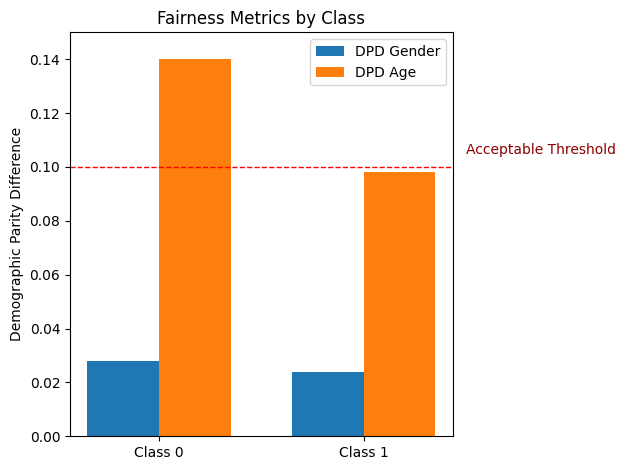

In [17]:
# Get protected attributes for test set
test_indices = X_test.index if hasattr(X_test, 'index') else range(len(X_test))
protected_test = protected_features.loc[test_indices]

# Run evaluation
evaluate_fairness(model, test_loader, protected_test)